### Boilerplate code - llm initiation

In [5]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv
from langchain_ollama import ChatOllama

load_dotenv("./env")

google_api_key = os.getenv("GOOGLE_API_KEY")
openai_api_key = os.getenv("OPENAI_API_KEY")

google_llm = ChatGoogleGenerativeAI(
    temperature=0, 
    model="gemini-2.5-flash", 
    api_key=google_api_key,
    max_tokens=200
)

openai_llm = ChatOpenAI(
    temperature=0, 
    model="gpt-5-mini", 
    api_key=openai_api_key
)

ollama_llm = ChatOllama(
    model="llama3.1:latest",
    temperature=0
)

# openai_llm.invoke("what is 2+2").content

### Human in the loop

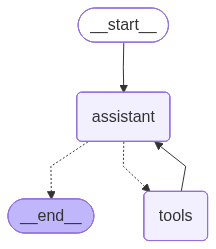

In [6]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display, Image
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage


def add(a:int, b:int) -> int:
    "Adds two numbers - a and b"
    return a + b

def subtract(a:int, b:int) -> int:
    "Subtracts two numbers- a and b"
    return a - b

def multiply(a:int, b:int) -> int:
    "Multiplies two numbers - a and b"
    return a * b

def divide(a:int, b:int) -> int:
    "Divides two numbers - a and b"
    return a / b

tools = [add, subtract, multiply, divide]

llm_with_tools = google_llm.bind_tools(tools)

memory = MemorySaver()


sys_msg = SystemMessage(content="You are a helpful assistant doing arithmetic operations from the given tools. Not anything else.")

def assistant(state: MessagesState) -> MessagesState:
    return llm_with_tools.invoke([sys_msg] + state['messages'])


builder = StateGraph(MessagesState)

builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))


builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "assistant")

graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))


In [4]:
config = {"configurable": {"thread_id": "123"}}

user_msg = {"messages": [HumanMessage(content="Add 10 with 10")]}

# for event in graph.stream(user_msg, config=config, stream_mode="values"):
#     event['messages'][-1].pretty_print()

res = graph.invoke(user_msg, config=config)

print(res.content)

KeyboardInterrupt: 

In [4]:
current_state = graph.get_state(config)
current_state.values

{'messages': [HumanMessage(content='Add 10 with 10', additional_kwargs={}, response_metadata={}, id='c79379f2-10a1-4bf2-8cce-d538aa9d4ad9')]}

##### Updating the state

In [ ]:
from langchain_core.messages import HumanMessage

graph.update_state(config, {"messages": HumanMessage(content="No. Add 10 with 20, then subtract the result with 5")})

##### Clearing messages in the state

In [ ]:
from langchain_core.messages import RemoveMessage

messages = graph.get_state(config).values['messages']
graph.update_state(config, {"messages": [RemoveMessage(id=msg.id) for msg in messages]})

In [ ]:
for event in graph.stream(None, config=config, stream_mode="values"):
    event['messages']

In [ ]:
user_approval = input("About to call assistant. Approve? (yes/no): ")

In [ ]:
while graph.get_state(config).next:
    state = graph.get_state(config)
    print(f"\n⏸ Paused. Next node: {state.next}")
    print(f"Last message: {state.values['messages'][-1]}")
    
    user_approval = input("\nApprove? (yes/no): ")
    if user_approval.lower() == "yes":
        for event in graph.stream(None, config=config, stream_mode="values"):
            event['messages'][-1].pretty_print()
    else:
        break
